## Introduction

The Boston Housing dataset is a well-known regression dataset containing information on 506 houses and 14 variables describing housing and neighborhood characteristics. The objective of this project is to analyze these features and develop machine learning models to accurately predict the median value of owner-occupied homes (MEDV).

## What to Expect

- Load and inspect the Boston Housing dataset.
- Understand the dataset structure and variables.
- Perform Exploratory Data Analysis (EDA).
- Clean and preprocess the data.
- Analyze relationships between variables.
- Split the data into training and testing sets.
- Train Linear Regression, Decision Tree, and Random Forest regression models.
- Evaluate model performance using MAE, MSE, RMSE, and R² Score.
- Improve model performance using hyperparameter tuning.
- Compare all models and select the best-performing model.

#### Import Required Libraries
The first step is to import the Python libraries required for data analysis, visualization, preprocessing, and machine learning.

In [1]:

import os
import numpy as np
import pandas as pd

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Data Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Regression Models
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# Hyperparameter Tuning
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV

# Model Evaluation
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Tree Visualization
from sklearn.tree import plot_tree

# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")

### Observation

All required libraries have been successfully imported. These libraries will be used throughout
the project for data analysis, visualization, model development,and evaluation.

In [2]:
file_path=r"C:\Users\user\OneDrive\Documents\boston_housing.csv.xls"
    
if os.path.exists(file_path):
    print("file found")
    df=pd.read_csv(file_path)
else:
    print("file not foud")

file found


In [3]:
df.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


### Observation

The output displays the first five records of the dataset, providing an overview of the variables and their corresponding values.

### Observation

The dataset has been loaded successfully. The first five rows provide an overview of the
available features and the target variable.

### Step 3: Data Inspection

The dataset is inspected to understand its structure, dimensions, data types, completeness,
and overall quality before preprocessing.

#### Checking the Dataset Shape

The shape of the dataset is examined to determine the number of observations (rows) and variables (columns).

In [4]:
print("Shape of Dataset:", df.shape)

Shape of Dataset: (506, 14)


### Observation

The dataset contains 506 observations and 14 variables.

In [5]:
df.tail()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat,medv
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273.0,21.0,391.99,9.67,22.4
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273.0,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273.0,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273.0,21.0,393.45,6.48,22.0
505,0.04741,0.0,11.93,0,0.573,6.030,80.8,2.5050,1,273.0,21.0,396.90,7.88,11.9


### Displaying Column Names

The names of all variables are displayed to understand the available features in the dataset.

In [6]:
print(df.columns)


Index(['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax',
       'ptratio', 'black', 'lstat', 'medv'],
      dtype='str')


### Observation

The dataset consists of 14 variables representing housing characteristics and the target variable (MEDV).

## Checking Data Types

The data type of each variable is examined to identify numerical and categorical variables before preprocessing.

In [7]:
df.dtypes

crim       float64
zn         float64
indus      float64
chas         int64
nox        float64
rm         float64
age        float64
dis        float64
rad          int64
tax        float64
ptratio    float64
black      float64
lstat      float64
medv       float64
dtype: object

### Observation

Most variables are numerical. The variables **CHAS** and **RAD** are stored as integers, which is appropriate because they represent categorical codes.

## Dataset Information

General information about the dataset is displayed, including the number of entries, data types, and memory usage.

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     506 non-null    float64
 1   zn       506 non-null    float64
 2   indus    506 non-null    float64
 3   chas     506 non-null    int64  
 4   nox      506 non-null    float64
 5   rm       506 non-null    float64
 6   age      506 non-null    float64
 7   dis      506 non-null    float64
 8   rad      506 non-null    int64  
 9   tax      506 non-null    float64
 10  ptratio  506 non-null    float64
 11  black    506 non-null    float64
 12  lstat    506 non-null    float64
 13  medv     506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB


### Observation

The dataset information confirms the number of observations, data types, and whether any missing values are present.

## Checking for Missing Values

The dataset is examined to determine whether any variables contain missing values.

In [9]:
df.isnull().sum()

crim       0
zn         0
indus      0
chas       0
nox        0
rm         0
age        0
dis        0
rad        0
tax        0
ptratio    0
black      0
lstat      0
medv       0
dtype: int64

### Observation

No missing values were found in the dataset; therefore, no missing value treatment was required.

## Checking for Duplicate Records

The dataset is checked for duplicate observations to ensure data quality.

In [10]:
df.duplicated().sum()

np.int64(0)

### Observation

No duplicate records were found in the dataset.

In [11]:
df.nunique()

crim       504
zn          26
indus       76
chas         2
nox         81
rm         446
age        356
dis        412
rad          9
tax         66
ptratio     46
black      357
lstat      455
medv       229
dtype: int64

## Statistical Summary

Descriptive statistics are generated to summarize the distribution of each numerical variable.

In [12]:
df.describe()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat,medv
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


### Observation

The statistical summary provides measures such as the mean, standard deviation, minimum, maximum, and quartiles for each variable.

## Step 4: Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is performed to understand the characteristics of the 
Boston Housing dataset before model development. It helps identify the distribution of 
variables, relationships between features, potential outliers, and factors that influence house prices.

### Pairwise Relationship Between Variables

A pairplot is used to visualize relationships among numerical variables in the dataset.
It helps identify trends, correlations, clusters, and possible linear relationships that may influence house prices.

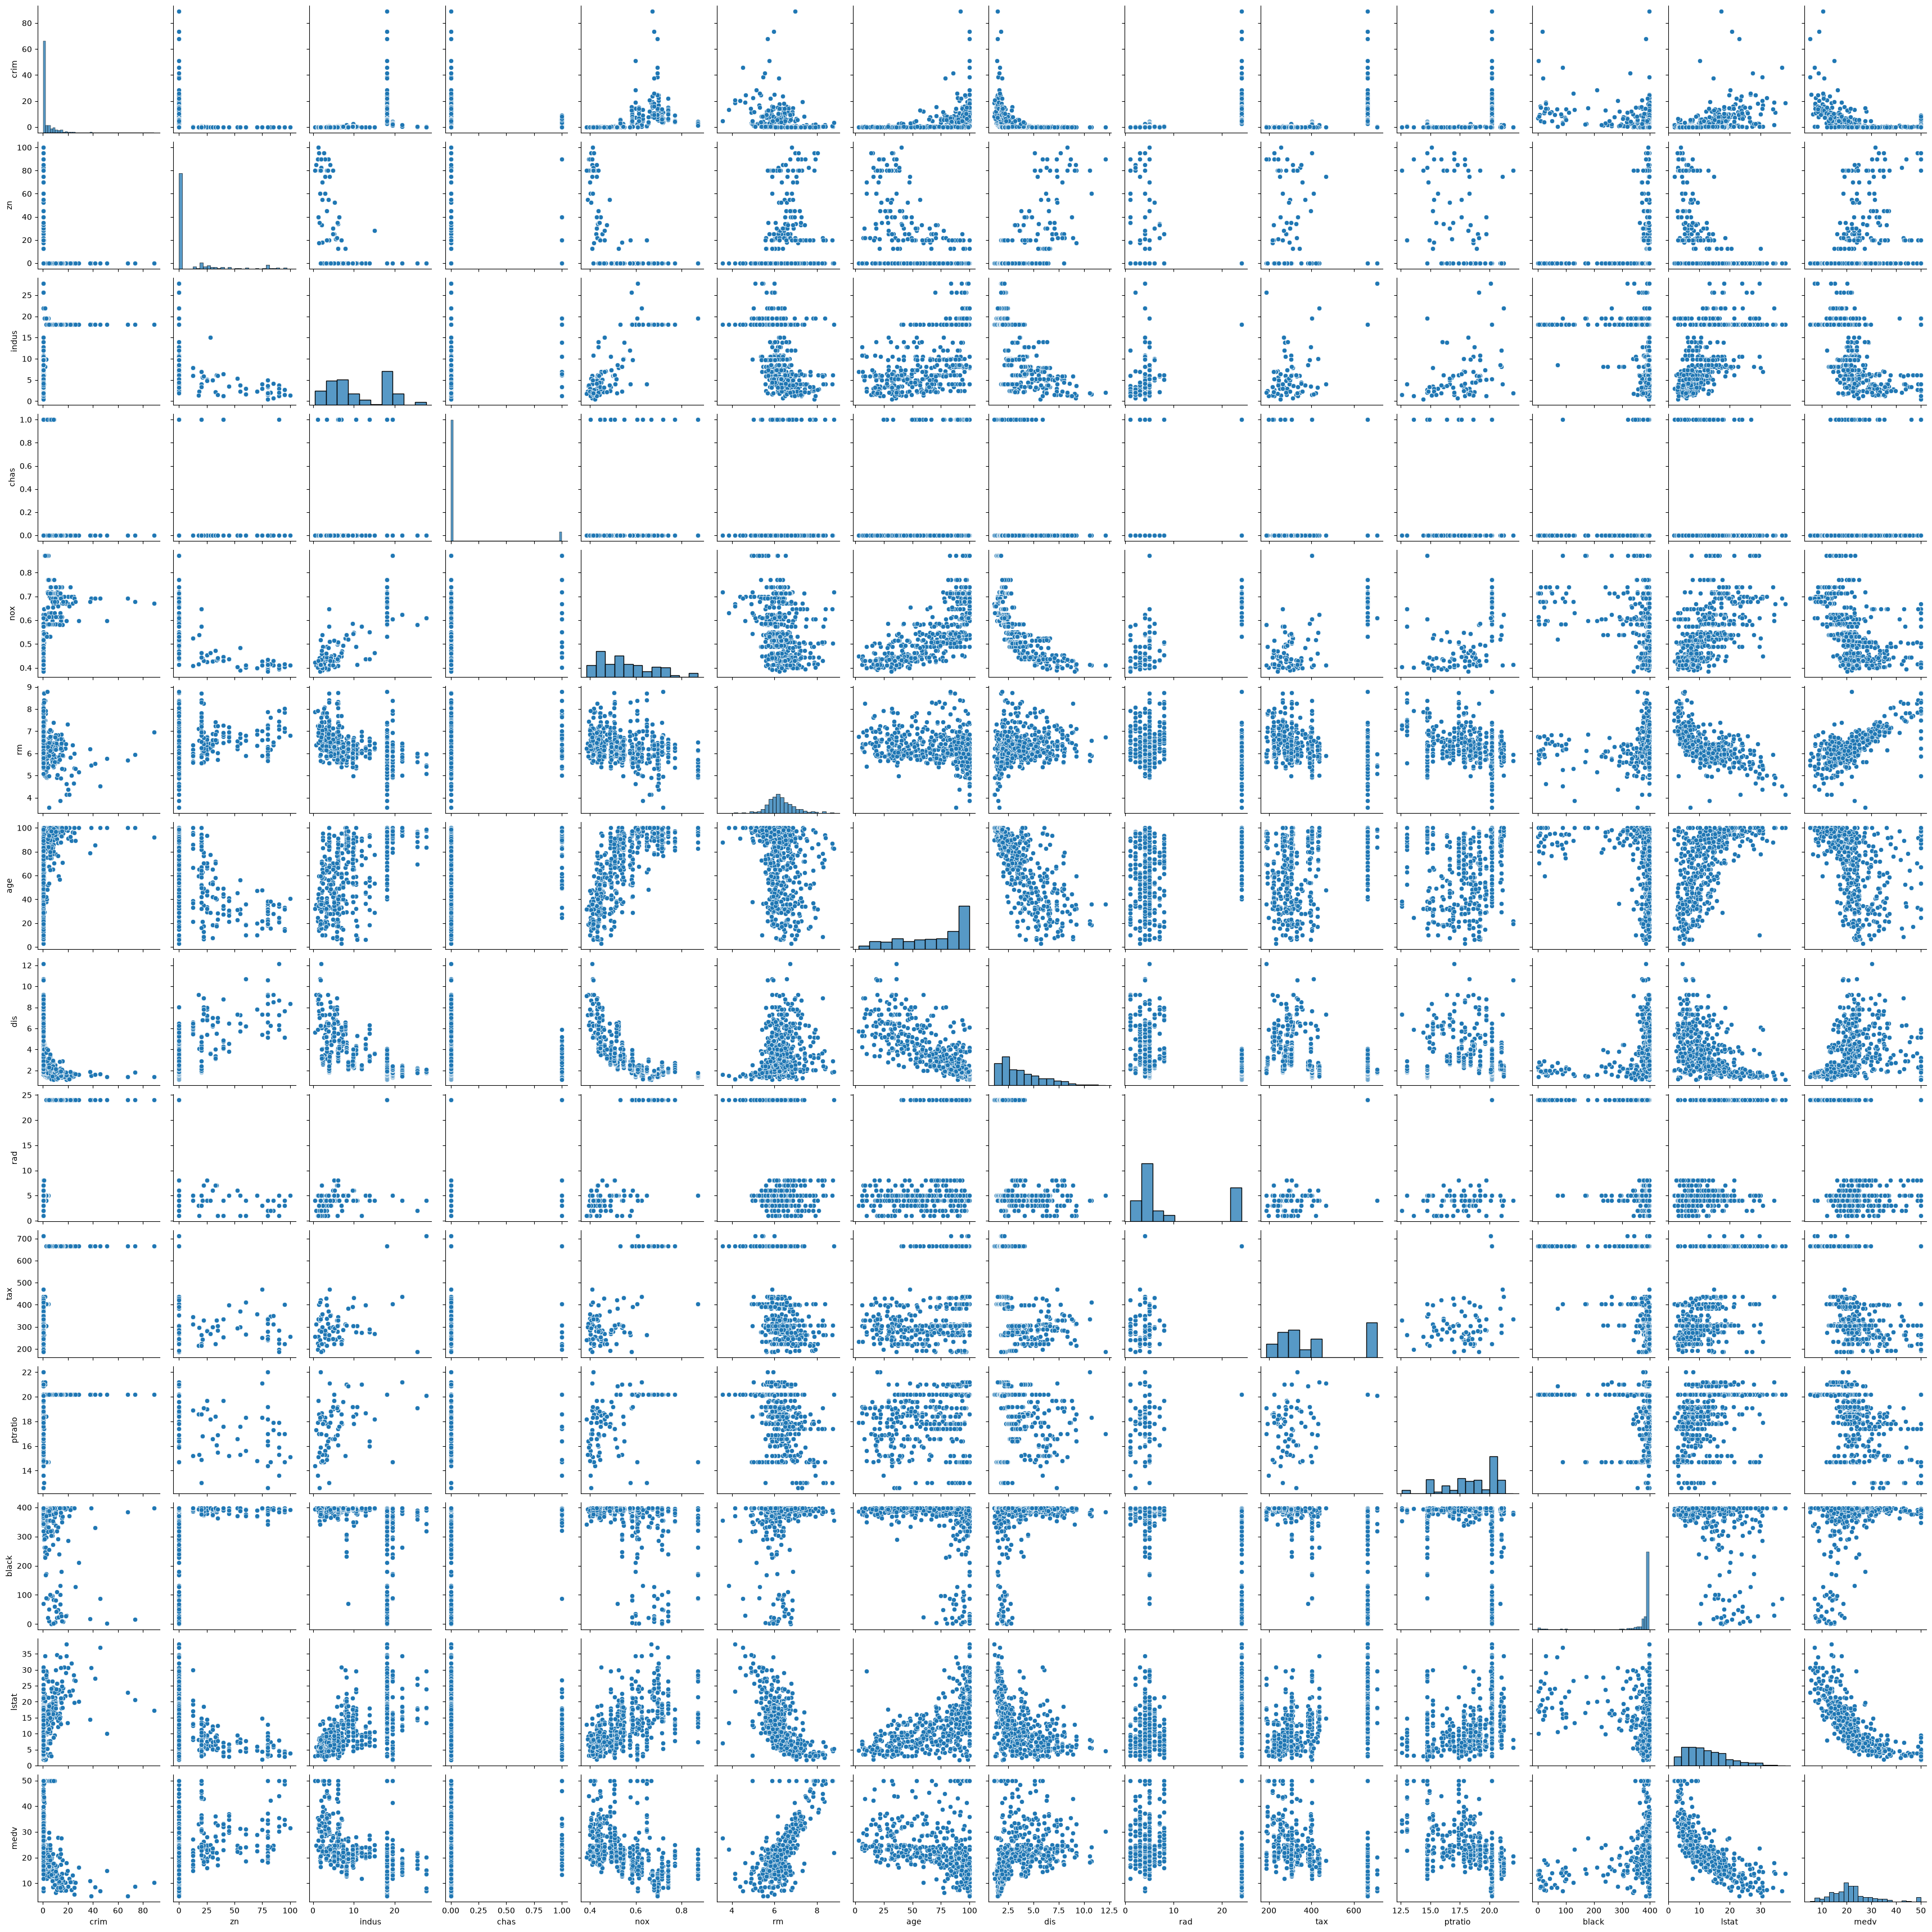

In [13]:
sns.pairplot(df)
plt.show()

### Observation

The pairplot illustrates the relationships among the numerical variables in the dataset. 
Some features appear to have strong linear relationships with house prices, while others 
show weaker or more scattered patterns. These relationships provide useful insights for
selecting appropriate regression models.

### Distribution of Variables

Histograms are used to examine the distribution of each variable.
They help identify skewness, spread, and potential abnormalities in the data.

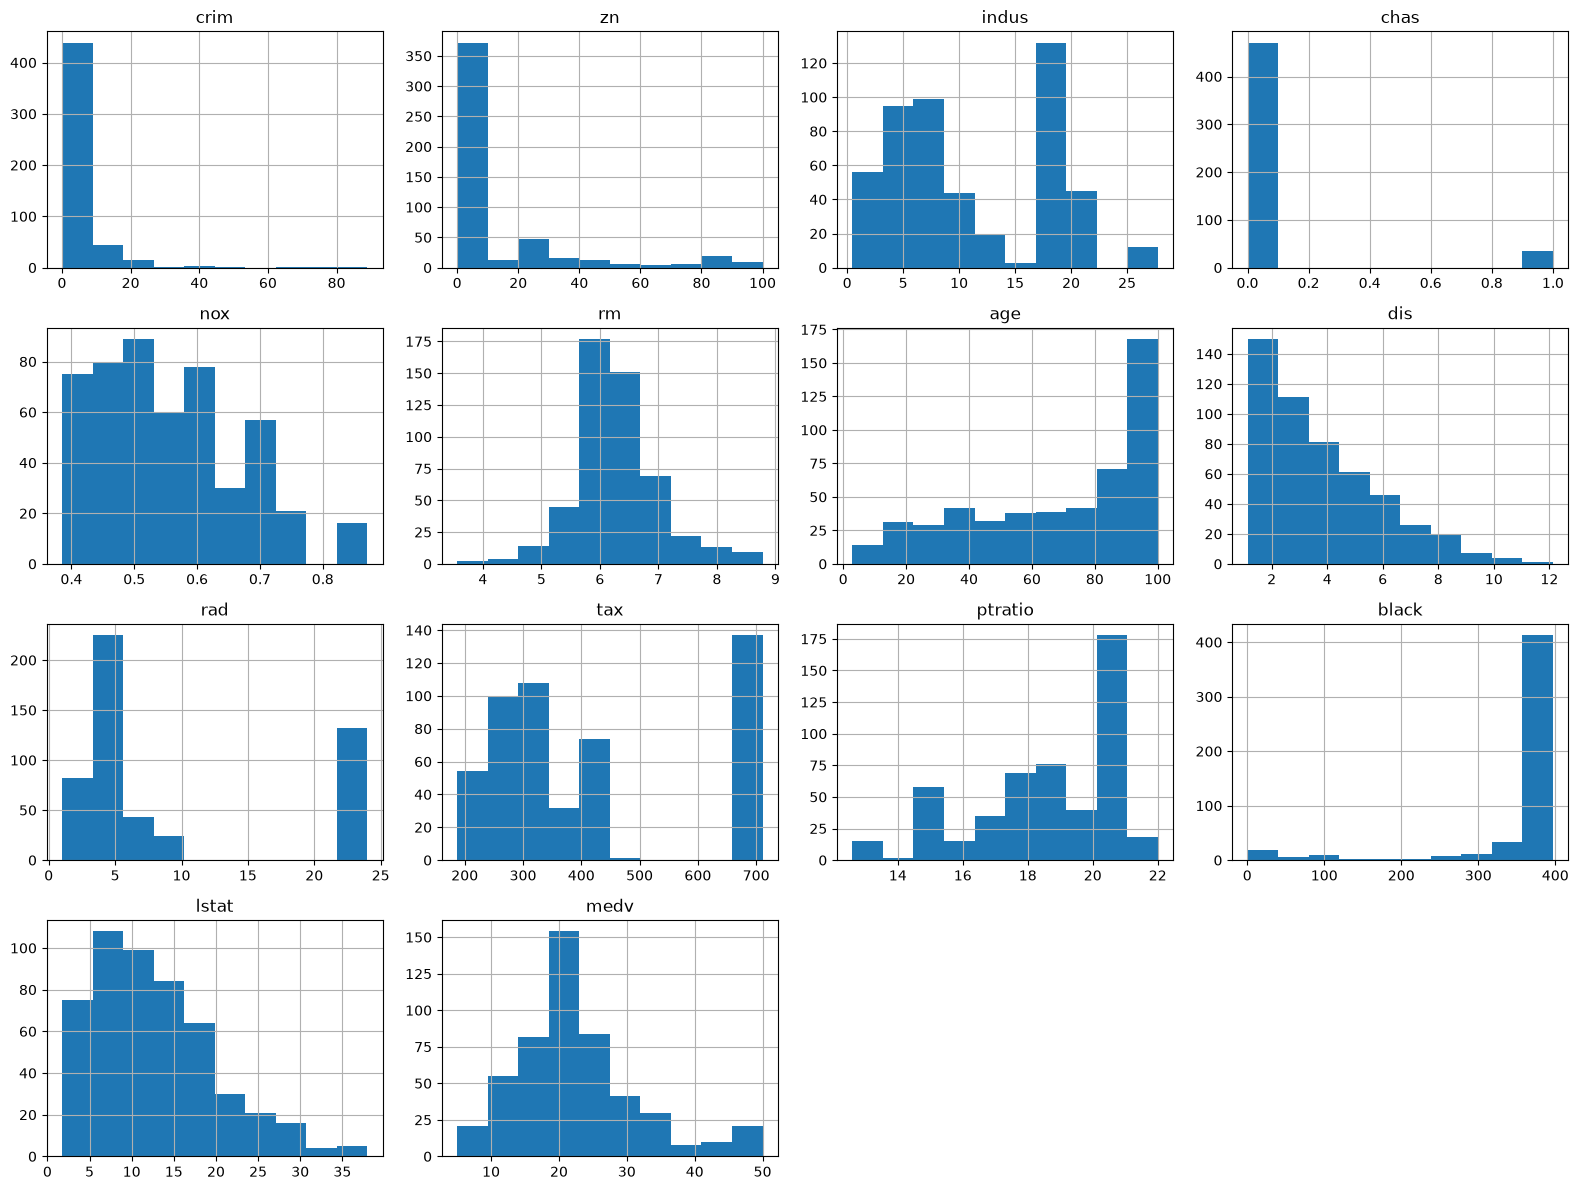

In [14]:
df.hist(figsize=(16,12))

plt.tight_layout()

plt.show()

### Observation

The histograms show the distribution of each feature in the dataset.
Some variables appear normally distributed, while others are positively or negatively skewed.
Understanding these distributions is important before model training.

### Outlier Detection

Boxplots summarize the distribution of numerical features and highlight potential outliers
that may require further investigation during preprocessing.

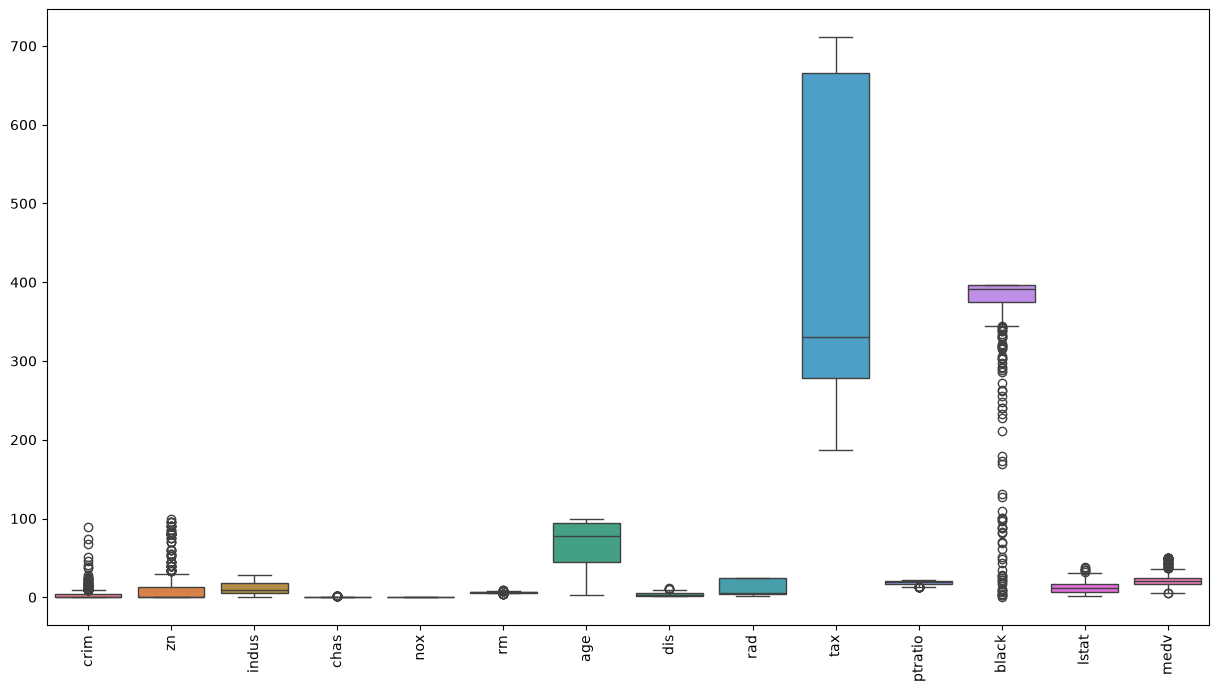

In [15]:
plt.figure(figsize=(15,8))

sns.boxplot(data=df)

plt.xticks(rotation=90)

plt.show()

### Observation

The boxplots reveal the presence of potential outliers in several variables. 
These observations will be examined during preprocessing to determine whether 
they should be retained or treated.

### Correlation Analysis

A correlation heatmap measures the strength and direction of relationships between variables.
Features with strong correlations to house prices are likely to contribute more to the prediction model.

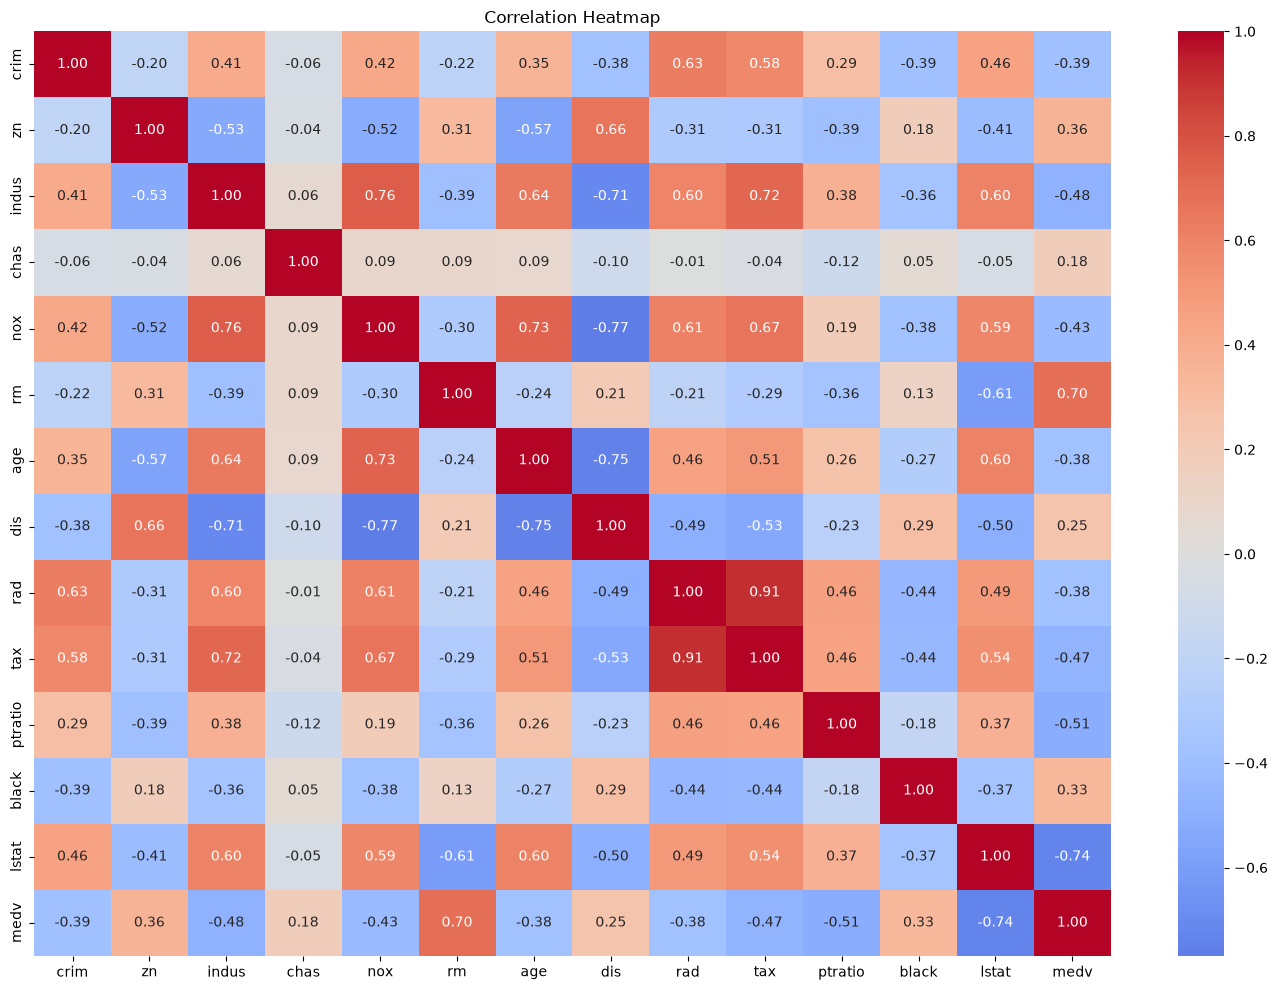

In [16]:
corr = df.corr()

plt.figure(figsize=(14,10))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    cbar=True
)

plt.title("Correlation Heatmap")

plt.tight_layout()
plt.show()

### Observation

The heatmap shows the correlation between variables. Features with strong positive or negative correlations with the target variable are likely to have greater influence on house price prediction and will be considered during feature selection.

### Relationship Between Features and House Prices

Scatter plots are used to examine the relationship between important predictor variables and the target variable. They help determine whether linear or non-linear relationships exist.

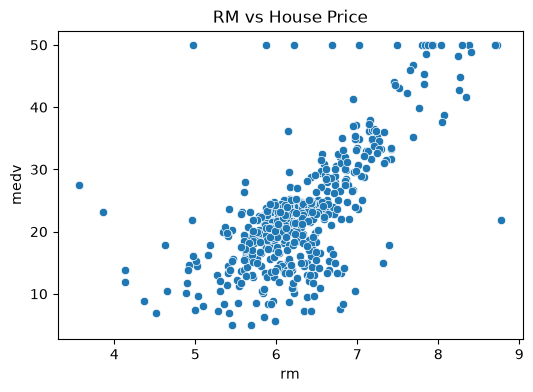

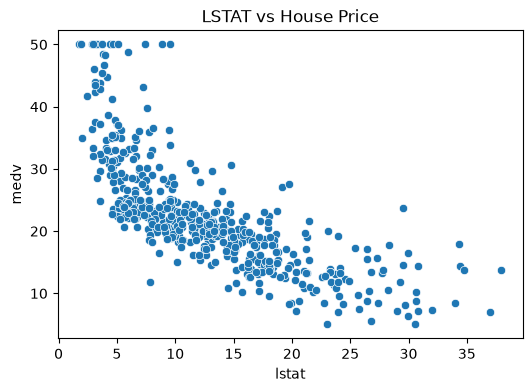

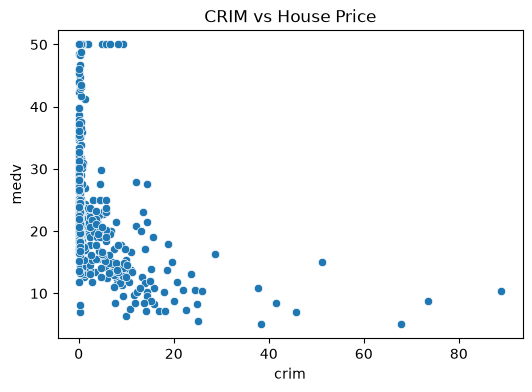

In [17]:
plt.figure(figsize=(6,4))
sns.scatterplot(data=df, x="rm", y="medv")
plt.title("RM vs House Price")
plt.show()

plt.figure(figsize=(6,4))
sns.scatterplot(data=df, x="lstat", y="medv")
plt.title("LSTAT vs House Price")
plt.show()

plt.figure(figsize=(6,4))
sns.scatterplot(data=df, x="crim", y="medv")
plt.title("CRIM vs House Price")
plt.show()

### Observation

The scatter plots illustrate how individual features relate to house prices. Some variables exhibit clear trends, indicating that they may be strong predictors in the regression models.

### Distribution of House Prices

The distribution of the target variable is examined to understand its range, spread, and overall shape before building regression models.

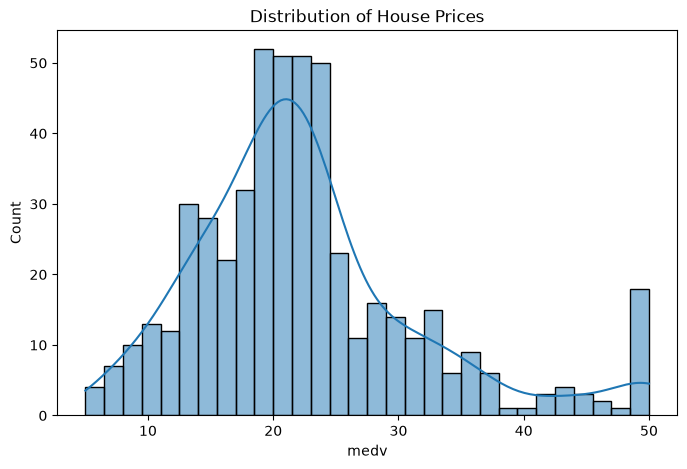

In [18]:
plt.figure(figsize=(8,5))

sns.histplot(df["medv"], bins=30, kde=True)

plt.title("Distribution of House Prices")

plt.show()

### Observation

The distribution of house prices provides insight into the range and frequency of property values in the dataset. This helps determine whether the target variable is normally distributed or skewed.

## Step 5: Data Preprocessing

Data preprocessing prepares the dataset for machine learning by checking for missing values, duplicate records, incorrect data types, and outliers. Proper preprocessing improves model performance and reliability.

### Checking Missing Values

Missing values can reduce model performance and introduce bias. Therefore, the dataset is examined to determine whether any variables contain missing observations.

In [19]:
print(df.isnull().sum())

crim       0
zn         0
indus      0
chas       0
nox        0
rm         0
age        0
dis        0
rad        0
tax        0
ptratio    0
black      0
lstat      0
medv       0
dtype: int64


### Observation

The output shows the number of missing values in each feature. since  all values are zero, the dataset is complete and no imputation is required.

### Checking Duplicate Records

Duplicate observations may introduce bias during model training. The dataset is checked to ensure that each observation is unique.

In [20]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


### Observation

The dataset is examined for duplicate records. And since no duplicates are found, all observations are retained for model development.

### Checking Data Types

The data types of all variables are verified to ensure they are suitable for regression modelling.

In [21]:
print(df.dtypes)

crim       float64
zn         float64
indus      float64
chas         int64
nox        float64
rm         float64
age        float64
dis        float64
rad          int64
tax        float64
ptratio    float64
black      float64
lstat      float64
medv       float64
dtype: object


### Observation

All predictor variables are numerical, making them suitable for regression analysis without the need for categorical encoding.

### Descriptive Statistics

Descriptive statistics provide a summary of the dataset, including measures such as the mean, standard deviation, minimum, maximum, and quartiles.

In [22]:
df.describe()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat,medv
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


### Observation

The descriptive statistics summarize the distribution of each variable and provide insight into the central tendency, variability, and overall range of the data.

### Detecting Outliers

Outliers are observations that differ significantly from the rest of the data. Detecting them helps determine whether they may influence the performance of regression models.

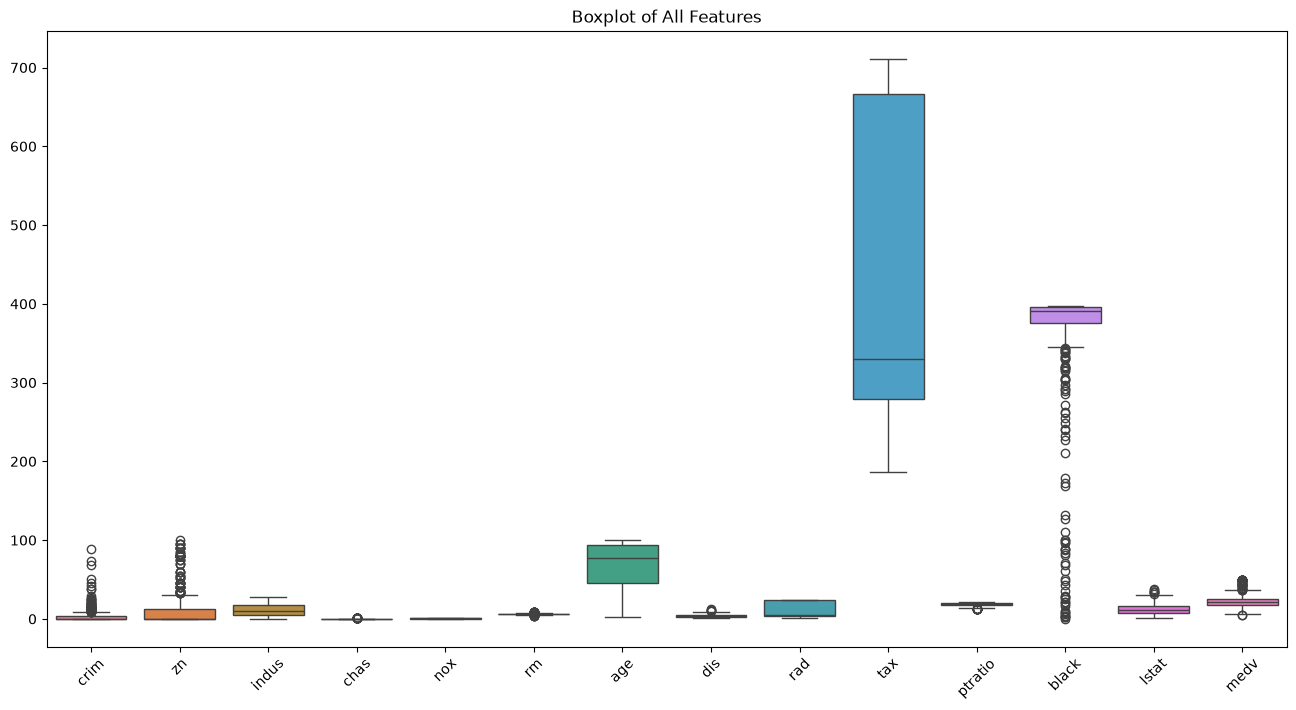

In [23]:
plt.figure(figsize=(16,8))
sns.boxplot(data=df)

plt.xticks(rotation=45)

plt.title("Boxplot of All Features")

plt.show()

### Observation

The boxplots reveal that several variables contain outliers. Since Random Forest and Decision Tree models are generally robust to outliers, they will be retained. Linear Regression may be affected, but the impact will be assessed through model evaluation.

### Separating Features and Target Variable

The dataset is divided into predictor variables (features) and the target variable. The target variable is the house price (`medv`), while all remaining variables are used as predictors.

In [24]:
X = df.drop("medv", axis=1)

y = df["medv"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (506, 13)
Target shape: (506,)


### Observation

The dataset has been successfully separated into predictor variables and the target variable, preparing it for model training.

### Feature Scaling

Feature scaling standardizes the numerical variables so that they have a mean of zero and a standard deviation of one. This improves numerical stability and benefits regression algorithms.

In [25]:

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print(X_scaled.shape)

(506, 13)


### Observation

The predictor variables have been standardized to improve model performance and ensure that all features contribute on a comparable scale.

## Step 6: Train-Test Split

The dataset is divided into training and testing sets. The training set is used to train the regression models, while the testing set is used to evaluate their predictive performance on unseen data.

In [26]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (404, 13)
X_test : (102, 13)
y_train: (404,)
y_test : (102,)


### Observation

The dataset has been split into training and testing sets using an 80:20 ratio. The training data will be used to build the regression models, while the testing data will evaluate their predictive performance.

## Step 7: Linear Regression

Linear Regression is a supervised machine learning algorithm used for predicting continuous values. It models the relationship between the predictor variables and the target variable by fitting a linear equation to the observed data.

### Training the Linear Regression Model

The model is trained using the training dataset so that it can learn the relationship between the predictor variables and the target variable.

In [27]:
lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](13,)","[-0.97, 0.7 , 0.28,...,-1.98, 1.13,-3.63]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,22.49
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,13
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,13
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](13,)","[49.49,24.72,22.79,..., 8.57, 8.35, 5. ]"


### Observation

The Linear Regression model has been successfully trained using the training dataset.

### Predicting House Prices

The trained model is used to predict house prices for the testing dataset.

In [28]:
lr_predictions = lr_model.predict(X_test)

### Observation

The model has generated predicted house prices for all observations in the testing dataset.

### Comparing Actual and Predicted Values

The first few predicted values are compared with the actual house prices to obtain an initial assessment of the model's performance.

In [29]:

comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": lr_predictions
})

comparison.head(10)

,Actual,Predicted
0,23.6,28.996724
1,32.4,36.025565
2,13.6,14.816944
3,22.8,25.031979
4,16.1,18.769880
5,20.0,23.254429
6,17.8,17.662538
7,14.0,14.341190
8,19.6,23.013207
9,16.8,20.632456


### Observation

The predicted values are generally close to the actual values, indicating that the model has captured the overall relationship between the predictors and the target variable.

### Model Evaluation

Regression metrics are used to evaluate the performance of the Linear Regression model.

In [30]:
mae = mean_absolute_error(y_test, lr_predictions)

mse = mean_squared_error(y_test, lr_predictions)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, lr_predictions)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE : 3.1890919658878487
MSE : 24.29111947497352
RMSE: 4.928602182665337
R² Score: 0.668759493535632


### Observation

The evaluation metrics quantify the prediction errors and the overall goodness of fit. Lower MAE, MSE, and RMSE values indicate better prediction accuracy, while an R² score closer to 1 indicates a stronger predictive model.

### Scatter Plot Actual vs Predicted House Prices

A scatter plot is used to compare the predicted house prices against the actual house prices. A good model produces points that lie close to the diagonal line.

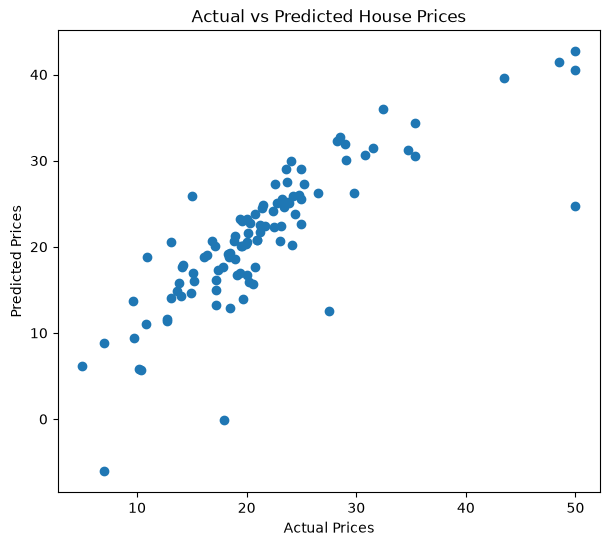

In [31]:
plt.figure(figsize=(7,6))

plt.scatter(y_test, lr_predictions)

plt.xlabel("Actual Prices")

plt.ylabel("Predicted Prices")

plt.title("Actual vs Predicted House Prices")

plt.show()

### Observation

The scatter plot demonstrates how closely the predicted values match the actual values. Points located near the diagonal indicate accurate predictions.

### Residual Analysis plot

Residuals represent the difference between the actual and predicted values. Examining the residuals helps determine whether the model makes unbiased predictions.

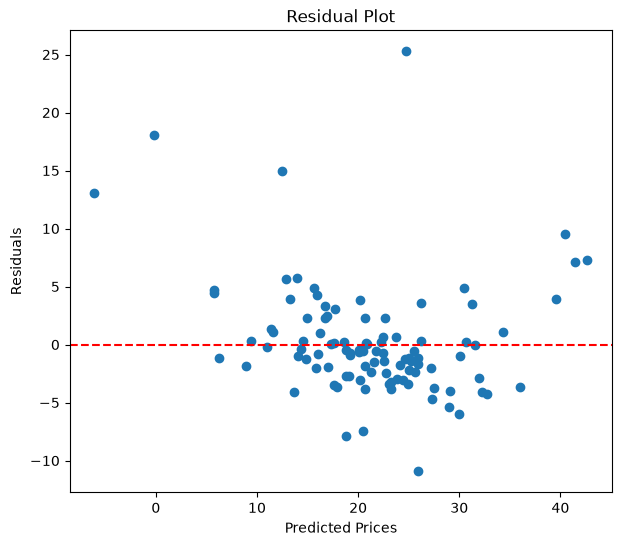

In [32]:
residuals = y_test - lr_predictions

plt.figure(figsize=(7,6))

plt.scatter(lr_predictions, residuals)

plt.axhline(y=0, color='red', linestyle='--')

plt.xlabel("Predicted Prices")

plt.ylabel("Residuals")

plt.title("Residual Plot")

plt.show()

### Observation

The residual plot helps assess the quality of the model. A random distribution of residuals around zero indicates that the model fits the data reasonably well without systematic bias.

# Step 8: Decision Tree Regression

Decision Tree Regression is a supervised machine learning algorithm that predicts continuous values by recursively splitting the dataset into smaller subsets based on feature values. Unlike Linear Regression, it can capture non-linear relationships between variables.

### Training the Decision Tree Regressor

The Decision Tree Regressor is trained using the training dataset to learn decision rules that predict house prices.

In [33]:
dt_model = DecisionTreeRegressor(random_state=42)

dt_model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes 

### Observation

The Decision Tree Regressor has been successfully trained using the training data.

### Predicting House Prices

The trained Decision Tree model is used to predict house prices for the testing dataset.

In [34]:
dt_predictions = dt_model.predict(X_test)
print(dt_predictions)

[26.4 33.1 15.2 22.  23.2 18.5 16.6 16.6 23.  22.  27.1 19.5  7.2 21.5
 19.  25.  21.4 10.5 44.  17.8 22.5 23.7 13.6 23.8 13.5 13.5 21.  14.6
 19.4 20.8 27.1 23.1 41.3 15.  13.3 15.6 33.4 18.5 21.7 24.8 19.8 29.9
 44.  19.3 22.  13.  14.3 24.1 17.4 35.1 21.7 34.9 16.6 29.9 43.1 19.5
 15.2 27.9 22.  23.1 26.6 33.4 29.8 19.3 22.8 14.4 15.4 22.9 28.  14.1
 21.8 28.7  8.3 18.6 21.5 10.5 19.8 50.  13.3  8.1 21.2 12.  19.4 10.5
 14.5 32.  14.8 23.  22.9 18.  23.3  8.8 19.8 17.5 16.2 19.8 50.  11.9
 11.7 10.2 19.  28.1]


### Observation

The model has generated predicted house prices for the testing dataset.

### Evaluating the Decision Tree Model

The performance of the Decision Tree Regressor is evaluated using MAE, MSE, RMSE, and R² Score.

In [35]:
mae_dt = mean_absolute_error(y_test, dt_predictions)

mse_dt = mean_squared_error(y_test, dt_predictions)

rmse_dt = np.sqrt(mse_dt)

r2_dt = r2_score(y_test, dt_predictions)

print("MAE :", mae_dt)
print("MSE :", mse_dt)
print("RMSE:", rmse_dt)
print("R² Score:", r2_dt)

MAE : 2.7245098039215683
MSE : 17.81558823529412
RMSE: 4.220851600719234
R² Score: 0.7570616506127126


### Observation

The evaluation metrics measure the prediction accuracy of the Decision Tree Regressor. Lower MAE, MSE, and RMSE values together with a higher R² Score indicate better predictive performance.

### Actual vs Predicted Values

A scatter plot compares the actual house prices with the predicted values produced by the Decision Tree model.

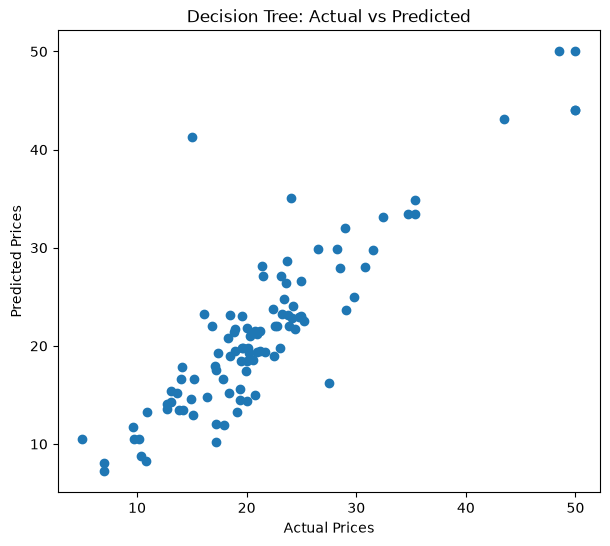

In [36]:
plt.figure(figsize=(7,6))

plt.scatter(y_test, dt_predictions)

plt.xlabel("Actual Prices")

plt.ylabel("Predicted Prices")

plt.title("Decision Tree: Actual vs Predicted")

plt.show()

### Observation

The scatter plot illustrates how closely the predicted values follow the actual house prices. A closer alignment indicates better prediction accuracy.

### Residual Analysis plot

Residuals are calculated as the difference between the actual and predicted values. Their distribution helps assess whether the model makes unbiased predictions.

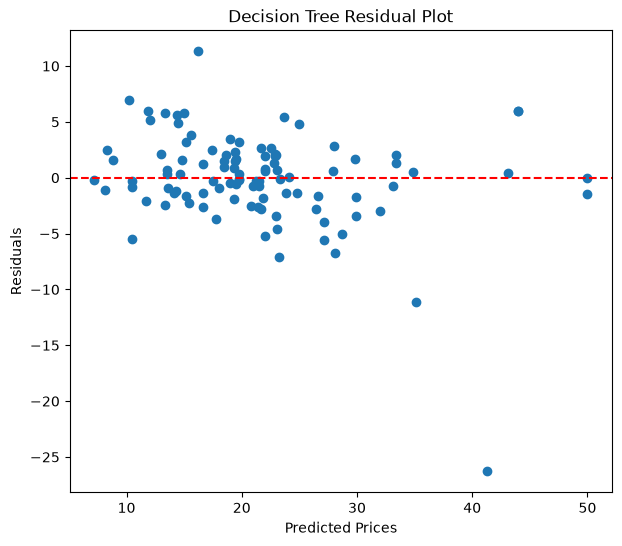

In [37]:
residuals_dt = y_test - dt_predictions

plt.figure(figsize=(7,6))

plt.scatter(dt_predictions, residuals_dt)

plt.axhline(y=0, color="red", linestyle="--")

plt.xlabel("Predicted Prices")

plt.ylabel("Residuals")

plt.title("Decision Tree Residual Plot")

plt.show()

### Observation

A random distribution of residuals around zero suggests that the model does not exhibit systematic prediction errors.

### Decision Tree Visualization

The trained Decision Tree is visualized to illustrate how it partitions the data and makes predictions based on the predictor variables.

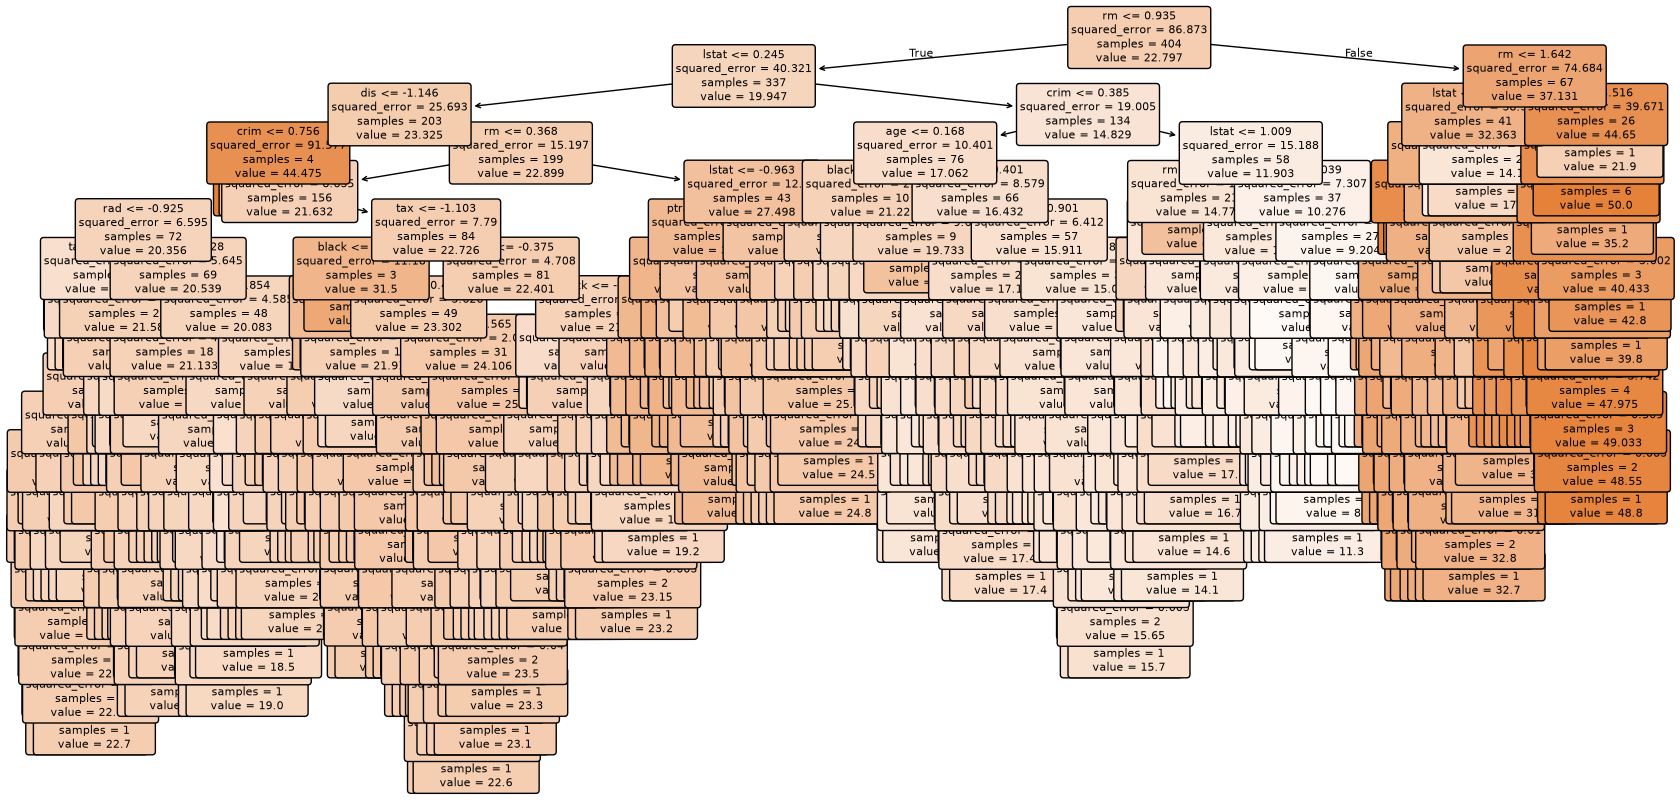

In [38]:
plt.figure(figsize=(20,10))

plot_tree(
    dt_model,
    feature_names=X.columns,
    filled=True,
    rounded=True,
    fontsize=8
)

plt.show()

### Observation

The visualization shows the sequence of decision rules used by the model to predict house prices. Each split is based on a feature value that reduces prediction error.

### Feature Importance

Feature importance measures the contribution of each predictor variable to the Decision Tree model. Features with higher importance have a greater influence on the predicted house prices.

In [39]:
importance_dt = pd.DataFrame({
    "Feature": X.columns,
    "Importance": dt_model.feature_importances_
})

importance_dt = importance_dt.sort_values(
    by="Importance",
    ascending=False
)

importance_dt

,Feature,Importance
5,rm,6.057924e-01
12,lstat,2.130401e-01
7,dis,6.460377e-02
0,crim,5.147472e-02
6,age,1.380815e-02
9,tax,1.278916e-02
11,black,1.148568e-02
10,ptratio,1.110779e-02
4,nox,6.320598e-03
2,indus,6.046697e-03


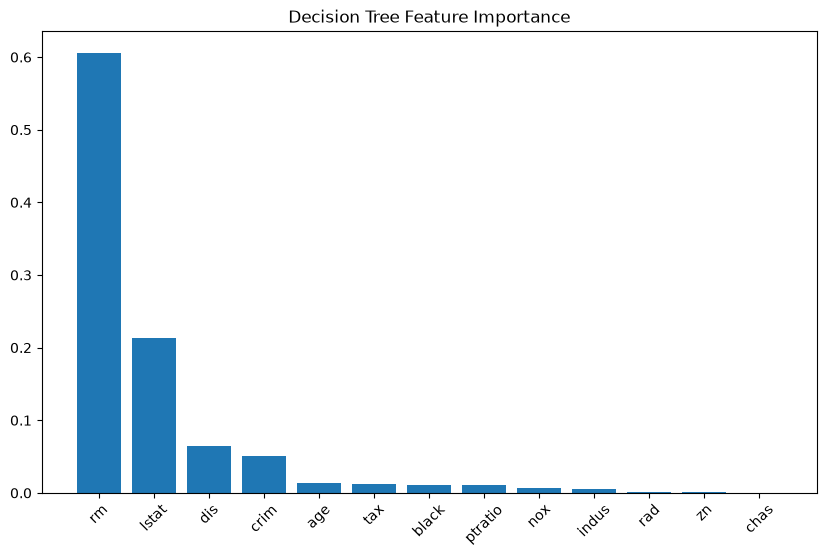

In [40]:
plt.figure(figsize=(10,6))

plt.bar(
    importance_dt["Feature"],
    importance_dt["Importance"]
)

plt.xticks(rotation=45)

plt.title("Decision Tree Feature Importance")

plt.show()

### Observation

The feature importance chart identifies the variables that contribute most to predicting house prices. Variables with higher importance scores have a stronger influence on the model.

## Hyperparameter Tuning (Decision Tree)

Hyperparameter tuning is performed to identify the optimal Decision Tree parameters that improve prediction accuracy and reduce overfitting. GridSearchCV systematically evaluates different parameter combinations using cross-validation.

In [67]:

# Parameter grid

param_grid = {
    "max_depth": [3, 5, 7, 10, None],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 4, 8],
    "criterion": ["squared_error", "friedman_mse"]
}

grid_dt = GridSearchCV(
    estimator=DecisionTreeRegressor(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)
grid_dt.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeR...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['squared_error', 'friedman_mse'], 'max_depth': [3, 5, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable add

### Observation

GridSearchCV evaluates several combinations of Decision Tree parameters using cross-validation. The model with the highest average R² score is selected as the optimal Decision Tree model.

### Best Hyperparameters

The optimal parameter values selected by GridSearchCV are displayed below.

In [68]:
print("Best Parameters:")
print(grid_dt.best_params_)

Best Parameters:
{'criterion': 'squared_error', 'max_depth': 10, 'min_samples_leaf': 8, 'min_samples_split': 20}


### Observation

The displayed parameters represent the best-performing Decision Tree configuration obtained during cross-validation.

### Training the Optimized Decision Tree

The optimized Decision Tree model is trained using the best parameter values identified by GridSearchCV.

In [43]:
best_dt = grid_dt.best_estimator_

best_dt.fit(X_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",20
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",8
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes m

### Observation

The optimized Decision Tree has been successfully trained using the selected hyperparameters.

In [44]:
best_dt_predictions = best_dt.predict(X_test)

### Evaluating the Optimized Decision Tree

The optimized model is evaluated using MAE, MSE, RMSE, and the R² Score.

In [45]:
mae_best_dt = mean_absolute_error(y_test, best_dt_predictions)

mse_best_dt = mean_squared_error(y_test, best_dt_predictions)

rmse_best_dt = np.sqrt(mse_best_dt)

r2_best_dt = r2_score(y_test, best_dt_predictions)

print("MAE :", mae_best_dt)
print("MSE :", mse_best_dt)
print("RMSE:", rmse_best_dt)
print("R² Score:", r2_best_dt)

MAE : 2.9546419602928893
MSE : 16.16012557217398
RMSE: 4.01996586704091
R² Score: 0.7796360030022647


### Observation

The optimized Decision Tree is evaluated using standard regression metrics. Its performance will later be compared with Linear Regression and Random Forest Regression.

### Performance Comparison

The performance of the Decision Tree before and after hyperparameter tuning is compared to determine whether optimization improved prediction accuracy.

In [46]:
comparison_dt = pd.DataFrame({
    "Model": ["Before Tuning", "After Tuning"],
    "MAE": [mae_dt, mae_best_dt],
    "MSE": [mse_dt, mse_best_dt],
    "RMSE": [rmse_dt, rmse_best_dt],
    "R² Score": [r2_dt, r2_best_dt]
})

comparison_dt

,Model,MAE,MSE,RMSE,R² Score
0,Before Tuning,2.724510,17.815588,4.220852,0.757062
1,After Tuning,2.954642,16.160126,4.019966,0.779636


### Observation

The optimized Decision Tree did not outperform the default model. The untuned model achieved lower prediction errors (MAE, MSE, and RMSE) and a higher R² Score. This suggests that the default Decision Tree parameters were already well suited to the dataset, while the tuned model may have become too constrained and underfit the data.

# Step 9: Random Forest Regressor

Random Forest Regression is an ensemble learning algorithm that combines the predictions of multiple Decision Trees to improve accuracy and reduce overfitting. By averaging the outputs of many trees, it produces more stable and reliable predictions than a single Decision Tree.

### Training the Random Forest Regressor

The Random Forest model is trained using the training dataset. It learns by constructing multiple Decision Trees and combining their predictions.

In [47]:


rf_model = RandomForestRegressor(
    random_state=42,
    n_estimators=100
)

rf_model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

### Observation

The Random Forest Regressor has been successfully trained using the training data.

### Making Predictions

The trained Random Forest model is used to predict house prices for the testing dataset.

In [48]:
rf_predictions = rf_model.predict(X_test)

### Observation

The model has generated predicted house prices for the testing dataset.

### Evaluating the Random Forest Model

The performance of the Random Forest Regressor is evaluated using MAE, MSE, RMSE, and the R² Score.

In [49]:
mae_rf = mean_absolute_error(y_test, rf_predictions)

mse_rf = mean_squared_error(y_test, rf_predictions)

rmse_rf = np.sqrt(mse_rf)

r2_rf = r2_score(y_test, rf_predictions)

print("MAE :", mae_rf)
print("MSE :", mse_rf)
print("RMSE:", rmse_rf)
print("R² Score:", r2_rf)

MAE : 2.044196078431373
MSE : 7.906532392156861
RMSE: 2.811855684802629
R² Score: 0.892184310539775


### Observation

The evaluation metrics indicate how accurately the Random Forest Regressor predicts house prices. Lower error values and a higher R² Score indicate better predictive performance.

### Actual vs Predicted House Prices

A scatter plot is used to compare the actual house prices with the predicted values produced by the Random Forest model.

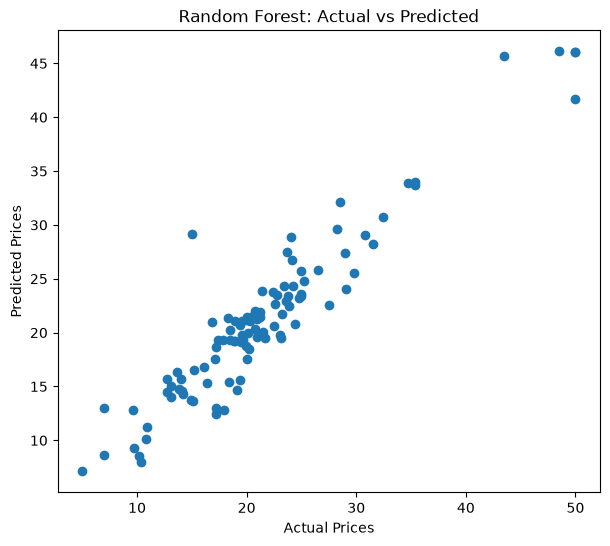

In [50]:
plt.figure(figsize=(7,6))

plt.scatter(y_test, rf_predictions)

plt.xlabel("Actual Prices")

plt.ylabel("Predicted Prices")

plt.title("Random Forest: Actual vs Predicted")

plt.show()

### Observation

The scatter plot illustrates how closely the predicted values align with the actual house prices. A tighter clustering around the ideal trend indicates better model performance.

### Residual Analysis

Residual analysis is performed to examine the differences between the actual and predicted values. A random distribution of residuals around zero indicates good model performance.

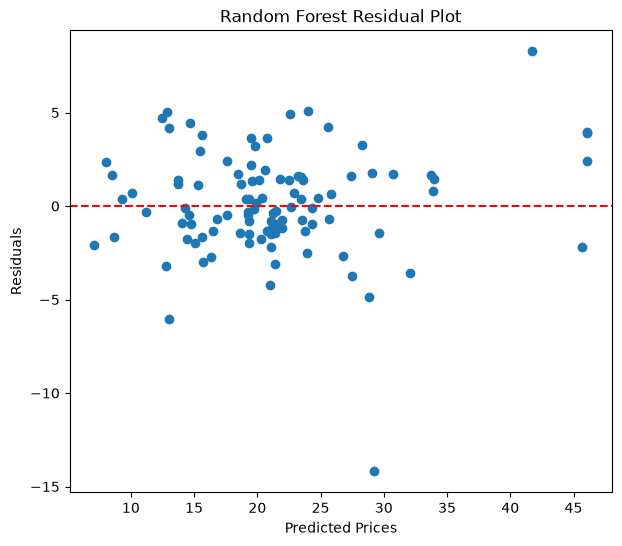

In [51]:
residuals_rf = y_test - rf_predictions

plt.figure(figsize=(7,6))

plt.scatter(rf_predictions, residuals_rf)

plt.axhline(y=0, color="red", linestyle="--")

plt.xlabel("Predicted Prices")

plt.ylabel("Residuals")

plt.title("Random Forest Residual Plot")

plt.show()

### Observation

A random distribution of residuals around the zero line indicates that the Random Forest model provides unbiased predictions with minimal systematic error.

### Feature Importance

Feature importance measures the contribution of each predictor variable to the Random Forest model. Variables with higher importance have a greater influence on house price prediction.

In [52]:
importance_rf = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

importance_rf = importance_rf.sort_values(
    by="Importance",
    ascending=False
)

importance_rf

,Feature,Importance
5,rm,0.504274
12,lstat,0.309532
7,dis,0.059881
0,crim,0.037635
10,ptratio,0.016242
9,tax,0.016142
4,nox,0.014987
6,age,0.013845
11,black,0.012754
2,indus,0.007742


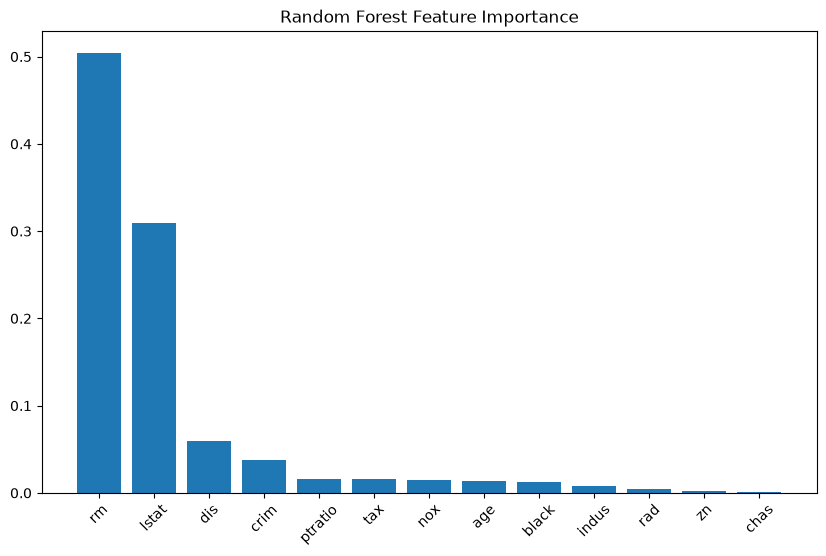

In [53]:
plt.figure(figsize=(10,6))

plt.bar(
    importance_rf["Feature"],
    importance_rf["Importance"]
)

plt.xticks(rotation=45)

plt.title("Random Forest Feature Importance")

plt.show()

### Observation

The feature importance chart ranks the predictor variables according to their contribution to the Random Forest model. Features with higher importance have a greater influence on predicting house prices.

## Hyperparameter Tuning using RandomizedSearchCV

RandomizedSearchCV is used to efficiently search a wide range of Random Forest hyperparameters. Instead of evaluating every possible combination, it randomly samples a specified number of combinations, reducing computation time while identifying promising parameter values.

In [54]:

# Parameter distribution
random_grid = {
    'n_estimators': [100, 200, 300, 400, 500],
    'max_depth': [None, 5, 10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

random_search = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_distributions=random_grid,
    n_iter=20,
    cv=5,
    scoring='r2',
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [None, 5, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for

### Observation

RandomizedSearchCV evaluates a random subset of parameter combinations using cross-validation. This approach efficiently identifies promising hyperparameter values while reducing computational cost.

### Best Hyperparameters from RandomizedSearchCV

The optimal parameter values obtained from RandomizedSearchCV are displayed below.

In [55]:

print(random_search.best_params_)

{'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 15}


### Training the Optimized Random Forest

The Random Forest model is retrained using the optimal hyperparameters identified through RandomizedSearchCV.

In [56]:
best_rf_random = random_search.best_estimator_

best_rf_random.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",15
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'log2'
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease 

In [57]:
random_predictions = best_rf_random.predict(X_test)

### Evaluating the Optimized Random Forest

The optimized Random Forest model is evaluated using regression performance metrics.

In [58]:
mae_random = mean_absolute_error(y_test, random_predictions)

mse_random = mean_squared_error(y_test, random_predictions)

rmse_random = np.sqrt(mse_random)

r2_random = r2_score(y_test, random_predictions)

print("MAE :", mae_random)
print("MSE :", mse_random)
print("RMSE:", rmse_random)
print("R² Score:", r2_random)

MAE : 1.9631518364001657
MSE : 10.087075264638532
RMSE: 3.1760156272661084
R² Score: 0.8624498173974459


### Comparison Before and After RandomizedSearchCV

The performance of the default Random Forest is compared with the optimized model obtained through RandomizedSearchCV.

In [59]:
comparison_random = pd.DataFrame({
    "Model": ["Default Random Forest",
              "RandomizedSearchCV"],
    "MAE": [mae_rf, mae_random],
    "MSE": [mse_rf, mse_random],
    "RMSE": [rmse_rf, rmse_random],
    "R² Score": [r2_rf, r2_random]
})

comparison_random

,Model,MAE,MSE,RMSE,R² Score
0,Default Random Forest,2.044196,7.906532,2.811856,0.892184
1,RandomizedSearchCV,1.963152,10.087075,3.176016,0.862450


### Observation

The comparison shows whether hyperparameter optimization improved the predictive performance of the Random Forest model.

## Hyperparameter Tuning using GridSearchCV

GridSearchCV performs an exhaustive search over a focused set of hyperparameter values. It evaluates every combination using cross-validation to identify the model with the best predictive performance.

In [60]:
param_grid = {
    'n_estimators': [100, 150, 200],
    'max_depth': [None, 10, 15],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt']
}

grid_rf = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [None, 10, ...], 'max_features': ['sqrt'], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 5], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose ver

In [61]:
print(grid_rf.best_params_)

{'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}


In [62]:
best_rf = grid_rf.best_estimator_

best_rf.fit(X_train, y_train)

,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decreas

In [63]:
grid_predictions = best_rf.predict(X_test)

In [64]:
mae_grid = mean_absolute_error(y_test, grid_predictions)

mse_grid = mean_squared_error(y_test, grid_predictions)

rmse_grid = np.sqrt(mse_grid)

r2_grid = r2_score(y_test, grid_predictions)

print("MAE :", mae_grid)
print("MSE :", mse_grid)
print("RMSE:", rmse_grid)
print("R² Score:", r2_grid)

MAE : 2.0306372549019596
MSE : 10.56057649999998
RMSE: 3.2497040634494674
R² Score: 0.8559930219758013


### Compare Default vs Random Search vs Grid Search

In [65]:
comparison_rf = pd.DataFrame({
    "Model": [
        "Default Random Forest",
        "RandomizedSearchCV",
        "GridSearchCV"
    ],
    "MAE": [
        mae_rf,
        mae_random,
        mae_grid
    ],
    "MSE": [
        mse_rf,
        mse_random,
        mse_grid
    ],
    "RMSE": [
        rmse_rf,
        rmse_random,
        rmse_grid
    ],
    "R² Score": [
        r2_rf,
        r2_random,
        r2_grid
    ]
})

comparison_rf

,Model,MAE,MSE,RMSE,R² Score
0,Default Random Forest,2.044196,7.906532,2.811856,0.892184
1,RandomizedSearchCV,1.963152,10.087075,3.176016,0.862450
2,GridSearchCV,2.030637,10.560576,3.249704,0.855993


### Observation

The Default Random Forest Regressor achieved the best overall performance among all the evaluated models. It produced the lowest MSE and RMSE values together with the highest R² Score, indicating superior predictive accuracy. Although the tuned Random Forest models achieved slightly lower MAE values, their higher RMSE and lower R² Scores suggest that the default model generalized better to the testing data.

## Best Model Selection

Among all the evaluated regression models, the Default Random Forest Regressor was selected as the final model. It achieved the highest R² Score (0.892), indicating that it explained approximately 89.2% of the variation in house prices. It also recorded the lowest RMSE and MSE values, demonstrating the best overall predictive performance.

# Conclusion

This project developed and compared three regression models for predicting house prices using the Boston Housing dataset. Exploratory Data Analysis and preprocessing were performed before training the models.

Linear Regression provided a baseline model but produced the lowest predictive accuracy. The Decision Tree Regressor improved the results by capturing non-linear relationships in the data. The Random Forest Regressor achieved the best performance, producing the highest R² Score and the lowest prediction errors.

Hyperparameter tuning was performed using both RandomizedSearchCV and GridSearchCV. Although these methods explored alternative parameter combinations, neither outperformed the default Random Forest model. Therefore, the Default Random Forest Regressor was selected as the final model because it provided the best balance between prediction accuracy and generalization.